In [2]:
%load_ext cudf.pandas

import numpy as np
import pandas as pd


import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv("https://raw.githubusercontent.com/jakevdp/PythonDataScienceHandbook/master/notebooks/data/births.csv")
df.head(10)

[  1131][12:36:30:049549][warning] Auto detection of compression type is supported only for file type buffers. For other buffer types, AUTO compression type assumes uncompressed input.


,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548
5,1969,1,3,M,4994
6,1969,1,4,F,4440
7,1969,1,4,M,4520
8,1969,1,5,F,4192
9,1969,1,5,M,4198


In [4]:
df.dtypes

year       int64
month      int64
day        int64
gender    object
births     int64
dtype: object

In [5]:
df.info()

<class 'cudf.core.dataframe.DataFrame'>
RangeIndex: 15547 entries, 0 to 15546
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    15547 non-null  int64
 1   month   15547 non-null  int64
 2   day     15067 non-null  int64
 3   gender  15547 non-null  object
 4   births  15547 non-null  int64
dtypes: int64(4), object(1)
memory usage: 563.7+ KB


In [6]:
# checking for null values

print(f"SIZE OF THE DATA : \n{df.shape}\n")
print(f"TOTAL NULL VALUES : \n{df.isna().sum()}\n")
print(f"PERCENTAGE OF NULL VALUES : \n{df.isna().mean() * 100} %\n")


SIZE OF THE DATA : 
(15547, 5)

TOTAL NULL VALUES : 
year        0
month       0
day       480
gender      0
births      0
dtype: int64

PERCENTAGE OF NULL VALUES : 
year      0.000000
month     0.000000
day       3.087412
gender    0.000000
births    0.000000
dtype: float64 %



In [7]:
# making column specific null checks
print(f"NULL VALUES IN DAY : \n{df['day'].isna().sum()}\n")
print(f"NULL VALUES IN GENDER : \n{df['gender'].isna().sum()}\n")

NULL VALUES IN DAY : 
480

NULL VALUES IN GENDER : 
0



In [8]:
# printing a specific data type
print(df.select_dtypes(include=['object']).isna().sum(), '\n')
print(df.select_dtypes(include=['int']).isna().sum())

gender    0
dtype: int64 

year        0
month       0
day       480
births      0
dtype: int64


In [9]:
# checking for integer columns without using 'select_dtypes(include=['...'])'
condition = (df.dtypes == 'int')
print(df.dtypes[condition].index.tolist())
print()


print(df.dtypes[df.dtypes == 'int'])



['year', 'month', 'day', 'births']

year      int64
month     int64
day       int64
births    int64
dtype: object


In [10]:
for i in df.columns:      # returns a list
    if df[i].dtypes == 'int':
        print(f"{i}")

year
month
day
births


In [11]:
df.select_dtypes(include=['object', 'int']).columns.tolist()

['year', 'month', 'day', 'gender', 'births']

In [12]:
# printing all the columns and their data types in a data frame 
df.dtypes.reset_index()

,index,0
0,year,int64
1,month,int64
2,day,int64
3,gender,object
4,births,int64


In [13]:
# printing only integer data type features 
df.select_dtypes(include=['int'])

,year,month,day,births
0,1969,1,1,4046
1,1969,1,1,4440
2,1969,1,2,4454
3,1969,1,2,4548
4,1969,1,3,4548
...,...,...,...,...
15542,2008,10,<NA>,183219
15543,2008,11,<NA>,158939
15544,2008,11,<NA>,165468
15545,2008,12,<NA>,173215


In [14]:
condition1 = ((df.dtypes == 'int') & (df.dtypes == 'object'))
condition2 = (df.dtypes == 'int')

# using condition1
df.loc[:, condition]

# using condition2
# df.loc[:, condition2]

,year,month,day,births
0,1969,1,1,4046
1,1969,1,1,4440
2,1969,1,2,4454
3,1969,1,2,4548
4,1969,1,3,4548
...,...,...,...,...
15542,2008,10,<NA>,183219
15543,2008,11,<NA>,158939
15544,2008,11,<NA>,165468
15545,2008,12,<NA>,173215


In [15]:
# printing only object data type features
df.select_dtypes(include='object')

,gender
0,F
1,M
2,F
3,M
4,F
...,...
15542,M
15543,F
15544,M
15545,F


In [16]:
# printing all the not null values
condition = (df.notna().all(axis=1))    # Create a 1D vertical list: "Are ALL columns in this row not null?", bcoz 'notna()' takes only 1D df

df.loc[condition]

,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548
...,...,...,...,...,...
15062,1988,12,29,M,5944
15063,1988,12,30,F,5742
15064,1988,12,30,M,6095
15065,1988,12,31,F,4435


In [17]:
obj = df.dropna()
obj

,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548
...,...,...,...,...,...
15062,1988,12,29,M,5944
15063,1988,12,30,F,5742
15064,1988,12,30,M,6095
15065,1988,12,31,F,4435


---

In [18]:
str1 = 'cat'
str2 = 'act'

In [19]:
sorted(str1)

['a', 'c', 't']

In [20]:
# checking for anagram

# type 1
def check(a, b):
    a = a.lower().replace(" ", "")
    b = b.lower().replace(" ", "")

    if sorted(a) == sorted(b):
        return True
    else:
        return False

# type 2
from collections import Counter
def check2(a, b):
    a = a.lower().replace(" ", "")
    b = b.lower().replace(" ", "")

    if counter(a) == counter(b):
        return True
    else:
        return False

In [21]:
df.loc[:, df.dtypes == 'object']

,gender
0,F
1,M
2,F
3,M
4,F
...,...
15542,M
15543,F
15544,M
15545,F


In [22]:
df

,year,month,day,gender,births
0,1969,1,1,F,4046
1,1969,1,1,M,4440
2,1969,1,2,F,4454
3,1969,1,2,M,4548
4,1969,1,3,F,4548
...,...,...,...,...,...
15542,2008,10,<NA>,M,183219
15543,2008,11,<NA>,F,158939
15544,2008,11,<NA>,M,165468
15545,2008,12,<NA>,F,173215


In [23]:
# male born in 2000

print(df[(df['year'] == 2000) & (df['gender'] == 'M')].shape)
df[(df['year'] == 2000) & (df['gender'] == 'M')]

(12, 5)


,year,month,day,gender,births
15332,2000,1,<NA>,M,169225
15334,2000,2,<NA>,M,162997
15336,2000,3,<NA>,M,174808
15338,2000,4,<NA>,M,162495
15340,2000,5,<NA>,M,175161
15342,2000,6,<NA>,M,175247
15344,2000,7,<NA>,M,179102
15346,2000,8,<NA>,M,184030
15348,2000,9,<NA>,M,177693
15350,2000,10,<NA>,M,176350


In [24]:
# males born btwn 1980 to 2000

df[((df['year'] >= 1980) & (df['year'] <= 2000)) & (df['gender'] == 'M')]

,year,month,day,gender,births
8387,1980,1,1,M,4227
8389,1980,1,2,M,4640
8391,1980,1,3,M,5087
8393,1980,1,4,M,5181
8395,1980,1,5,M,4426
...,...,...,...,...,...
15346,2000,8,<NA>,M,184030
15348,2000,9,<NA>,M,177693
15350,2000,10,<NA>,M,176350
15352,2000,11,<NA>,M,170206


In [25]:
# children born more than 15000 btwn 2000 to 2008

df[((df['year'] >= 2000) & (df['year'] <= 2008)) & (df['births'] > 15000)]


,year,month,day,gender,births
15331,2000,1,<NA>,F,161288
15332,2000,1,<NA>,M,169225
15333,2000,2,<NA>,F,154694
15334,2000,2,<NA>,M,162997
15335,2000,3,<NA>,F,166124
...,...,...,...,...,...
15542,2008,10,<NA>,M,183219
15543,2008,11,<NA>,F,158939
15544,2008,11,<NA>,M,165468
15545,2008,12,<NA>,F,173215


In [26]:
# born btwn 2000 to 2008, showing only year and birth column

condition = ((df['year'] >= 2000) & (df['year'] <= 2008))
df.loc[condition, ['year','births']]


,year,births
15331,2000,161288
15332,2000,169225
15333,2000,154694
15334,2000,162997
15335,2000,166124
...,...,...
15542,2008,183219
15543,2008,158939
15544,2008,165468
15545,2008,173215


In [27]:
condition = (df['births']  >= 180000)
df.loc[condition, ['year', 'gender', 'births']]

,year,gender,births
15080,1989,M,183063
15082,1989,M,188074
15084,1989,M,182962
15100,1990,M,181366
15104,1990,M,188837
...,...,...,...
15537,2008,F,182713
15538,2008,M,191315
15540,2008,M,188964
15542,2008,M,183219


In [28]:
condition = (df['year'] == 2008)
print(df.loc[condition, ['year', 'births']].shape[0])


df.loc[condition, ['year', 'births']]

24


,year,births
15523,2008,174255
15524,2008,182789
15525,2008,165669
15526,2008,173434
15527,2008,172053
15528,2008,179129
15529,2008,169585
15530,2008,177399
15531,2008,173141
15532,2008,182294


In [29]:
df.columns

Index(['year', 'month', 'day', 'gender', 'births'], dtype='object')

In [30]:
# plotting a pivot table
data = df[df['year'] >= 2000]

data.pivot_table(index='year', columns=['month'], values='births')


month,1,2,3,4,5,6,7,8,9,10,11,12
year,,,,,,,,,,,,
2000,165256.5,158845.5,170466.0,158766.5,170802.0,170802.5,174714.5,180269.0,174052.0,172194.5,167146.0,168596.5
2001,167806.0,151949.5,169544.0,162019.5,172246.5,165768.5,175793.0,181191.0,171543.0,172299.5,162107.0,163498.0
2002,165544.5,152186.0,165947.0,162424.5,169727.5,164026.5,179110.0,179972.5,174698.0,173162.0,159524.5,167365.0
2003,165152.0,153831.0,168709.0,165294.5,173612.5,168972.0,182400.0,180341.5,180099.0,177291.5,160308.5,172034.5
2004,166704.0,158155.0,173427.0,166929.0,169084.0,172699.0,180025.0,178037.5,178351.5,174555.0,168154.5,173332.0
2005,166015.0,155048.0,174940.5,166513.5,173415.0,175723.0,178850.0,185022.5,182057.0,172646.5,168154.5,174424.0
2006,170449.5,159922.5,178680.0,165197.5,178031.5,179448.5,184316.5,194240.5,187694.5,184030.0,176244.5,178357.0
2007,177780.0,163697.0,180705.0,169397.5,181459.0,179612.5,190178.0,195558.5,183812.0,185034.5,177163.5,177606.5
2008,178522.0,169551.5,175591.0,173492.0,177717.5,174612.5,188052.5,187014.0,184330.0,179266.5,162203.5,177225.0


In [31]:
# plotting a pivot table
data = df[df['year'] >= 2000]

data.pivot_table(index='year', columns=['month'], values='births', margins=True, margins_name='SUM OF ALL BIRTHS', aggfunc='sum')


month,1,2,3,4,5,6,7,8,9,10,11,12,SUM OF ALL BIRTHS
year,,,,,,,,,,,,,
2000,330513,317691,340932,317533,341604,341605,349429,360538,348104,344389,334292,337193,4063823
2001,335612,303899,339088,324039,344493,331537,351586,362382,343086,344599,324214,326996,4031531
2002,331089,304372,331894,324849,339455,328053,358220,359945,349396,346324,319049,334730,4027376
2003,330304,307662,337418,330589,347225,337944,364800,360683,360198,354583,320617,344069,4096092
2004,333408,316310,346854,333858,338168,345398,360050,356075,356703,349110,336309,346664,4118907
2005,332030,310096,349881,333027,346830,351446,357700,370045,364114,345293,336309,348848,4145619
2006,340899,319845,357360,330395,356063,358897,368633,388481,375389,368060,352489,356714,4273225
2007,355560,327394,361410,338795,362918,359225,380356,391117,367624,370069,354327,355213,4324008
2008,357044,339103,351182,346984,355435,349225,376105,374028,368660,358533,324407,354450,4255156


In [32]:
# printing sum of total births in every year

df.groupby('year')['births'].sum().reset_index()

,year,births
0,1969,3600206
1,1970,3737800
2,1971,3563548
3,1972,3266235
4,1973,3146125
5,1974,3170631
6,1975,3153556
7,1976,3176476
8,1977,3332159
9,1978,3338300


In [33]:
data = df[df['year'] >= 2000]

data.groupby('year')['births'].sum().reset_index()

,year,births
0,2000,4063823
1,2001,4031531
2,2002,4027376
3,2003,4096092
4,2004,4118907
5,2005,4145619
6,2006,4273225
7,2007,4324008
8,2008,4255156


In [34]:
# sum of all the children born in 2008

data = df[df['year'] == 2008]['births']

print(f"SUM OF ALL THE CHILDREN BORN IN 2008 : {data.sum()}")
data.reset_index()

SUM OF ALL THE CHILDREN BORN IN 2008 : 4255156


,index,births
0,15523,174255
1,15524,182789
2,15525,165669
3,15526,173434
4,15527,172053
5,15528,179129
6,15529,169585
7,15530,177399
8,15531,173141
9,15532,182294


In [35]:
# sum of all the children born in 2008

df.loc[df['year'] == 2008, 'births'].sum()

np.int64(4255156)

In [36]:
df.columns

Index(['year', 'month', 'day', 'gender', 'births'], dtype='object')

In [37]:
data = df[df['year'] >= 2000]

data.pivot_table(index='year', columns='gender', values='births', margins=True, margins_name='SUM', aggfunc='sum')

gender,F,M,SUM
year,,,
2000,1984255,2079568,4063823
2001,1970770,2060761,4031531
2002,1966519,2060857,4027376
2003,1999387,2096705,4096092
2004,2010710,2108197,4118907
2005,2022892,2122727,4145619
2006,2084957,2188268,4273225
2007,2111890,2212118,4324008
2008,2077929,2177227,4255156


In [38]:
condition = df['year'] >= 2000

data = df.loc[condition, ['year', 'births']]
data

,year,births
15331,2000,161288
15332,2000,169225
15333,2000,154694
15334,2000,162997
15335,2000,166124
...,...,...
15542,2008,183219
15543,2008,158939
15544,2008,165468
15545,2008,173215


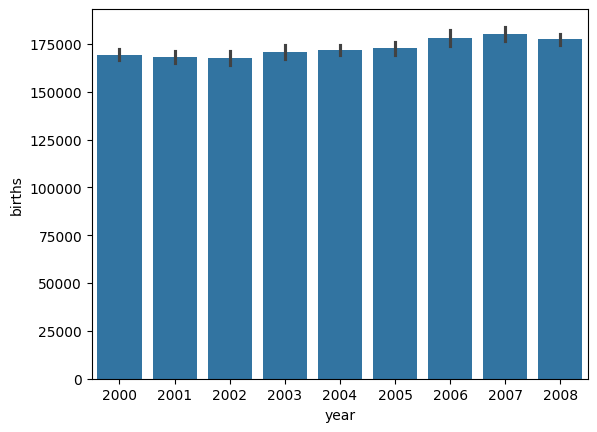

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.barplot(x=data['year'], y=data['births'])
plt.show()

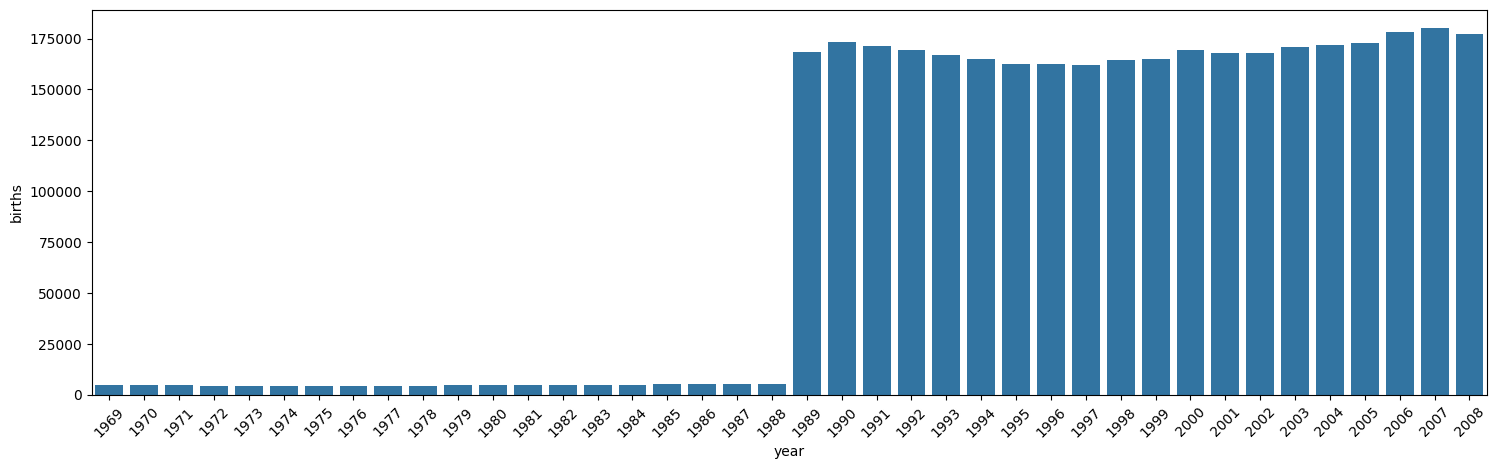

In [43]:
plt.figure(figsize=(18,5))
sns.barplot(x=df['year'], y=df['births'], errorbar=None)
plt.xticks(rotation=45)
plt.show()

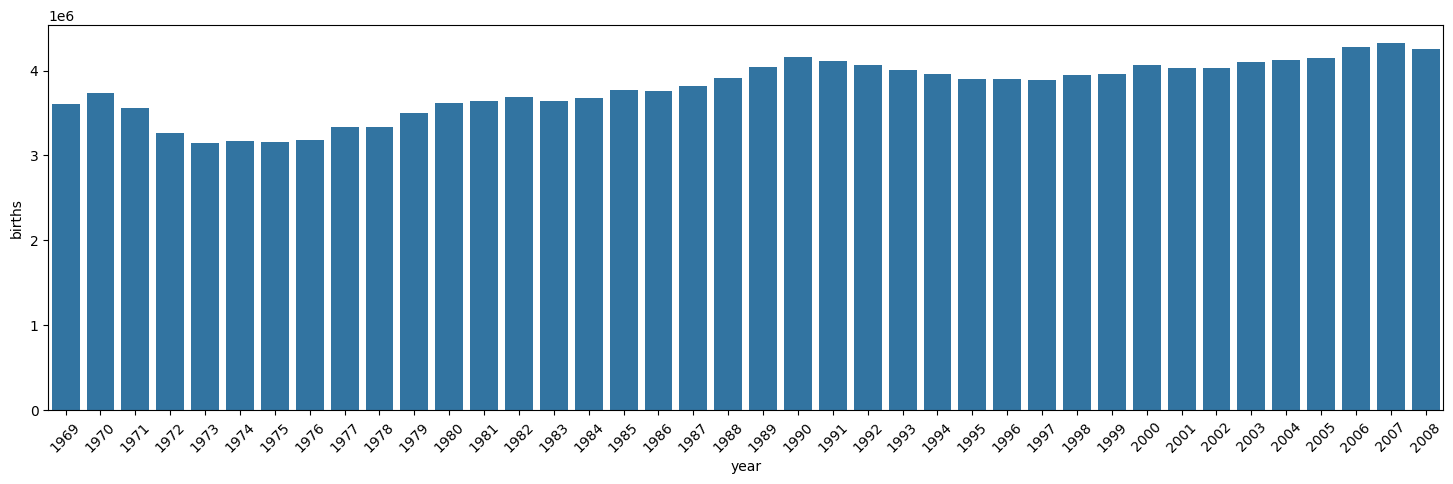

In [42]:
plt.figure(figsize=(18,5))
sns.barplot(x=df['year'], y=df['births'], estimator='sum', errorbar=None)
plt.xticks(rotation=45)
plt.show()